In [1]:
#Data ที่ใช้เป็น version เเรก
#602307-ชินาธิป,0.5265,ใช้ Codex App ในกระบวนการ OCR จนถึงเเปลงเป็น JSON (เลยไม่มีส่วนของ code) เเละมีการลบรูปภาพบางส่วนที่ไม่เกี่ยวข้องหรือไม่ควรนำมาใช้งานออกไป
from google.colab import drive
#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **ทำลบรูปภาพบางส่วนที่ไม่เกี่ยวข้องหรือไม่ควรนำมาใช้งานออกไป**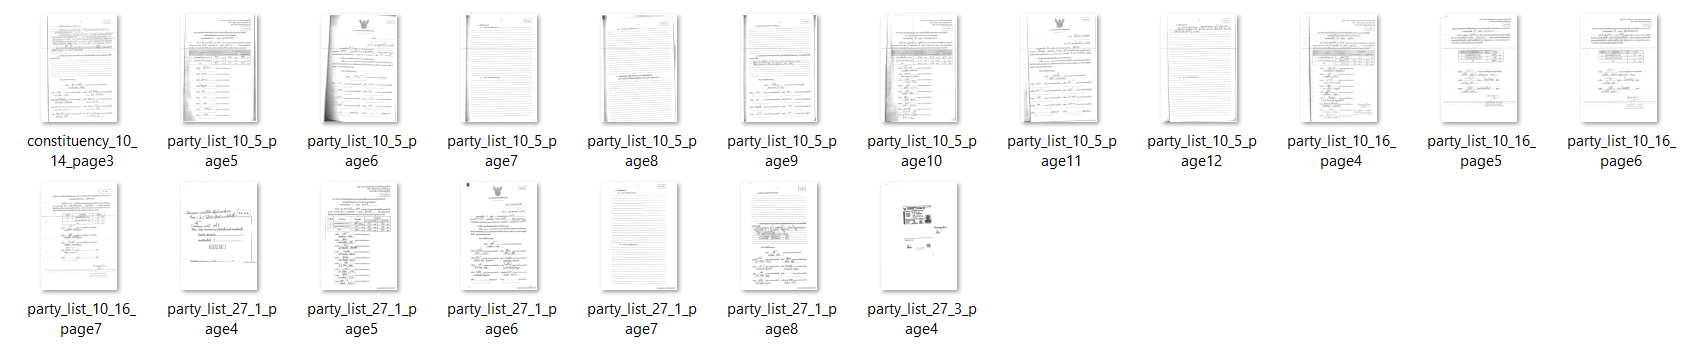

# **ทำการ enhance the contrast in Gray scale ส่วนของรูปภาพที่ต้องการ**

In [ ]:
import os
from PIL import Image, ImageEnhance

# Define input and output directories
input_dir = '/content/drive/MyDrive/hack2/before contrast'
output_dir = '/content/new/new contrast'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

# Define processing parameters
contrast_factor = 3.5
# threshold_value = 128 # A common threshold value for 8-bit grayscale images

# Get a list of image files to process
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

if not image_files:
    print(f"No image files found in '{input_dir}'. Please ensure images are present.")
else:
    print(f"Found {len(image_files)} image(s) to process in '{input_dir}'.")

    # Process each image in the directory
    for filename in image_files:
        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, filename)

        try:
            # Load the image
            original_image = Image.open(input_path)

            # Convert to grayscale
            grayscale_image = original_image.convert('L')

            # Enhance contrast
            enhancer = ImageEnhance.Contrast(grayscale_image)
            contrast_enhanced_image = enhancer.enhance(contrast_factor)

            # Apply thresholding (removed)
            # thresholded_image = contrast_enhanced_image.point(lambda p: p > threshold_value and 255)

            # Save the processed (contrast-enhanced) image
            contrast_enhanced_image.save(output_path)
            print(f"Processed and saved '{filename}' to '{output_path}'.")

        except Exception as e:
            print(f"Error processing '{filename}': {e}")

print("Batch processing complete.")


Output directory '/content/new/new contrast' ensured.
Found 4 image(s) to process in '/content/drive/MyDrive/hack2/before contrast'.
Processed and saved 'party_list_30_13.png' to '/content/new/new contrast/party_list_30_13.png'.
Processed and saved 'party_list_30_13_page2.png' to '/content/new/new contrast/party_list_30_13_page2.png'.
Processed and saved 'party_list_30_13_page3.png' to '/content/new/new contrast/party_list_30_13_page3.png'.
Processed and saved 'party_list_30_10_page2.png' to '/content/new/new contrast/party_list_30_10_page2.png'.
Batch processing complete.


# **ทำการ enhance the contrast in Gray scale เเละ thresholding ส่วนของรูปภาพที่ต้องการ**

In [ ]:
from PIL import Image, ImageEnhance
import os

# Define the input directory containing images
input_dir = '/content/drive/MyDrive/hack2/before contrast + threshold'

# Define the output directory for processed images
output_dir = '/content/new/new_thresholded_batch'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

# Define processing parameters
contrast_factor = 3.5
threshold_value = 128

# Get a list of image files to process
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

if not image_files:
    print(f"No image files found in '{input_dir}'. Please ensure images are present.")
elif len(image_files) == 1:
    print(f"Found 1 image to process in '{input_dir}'.")
else:
    print(f"Found {len(image_files)} images to process in '{input_dir}'.")

# Process each image in the directory
for filename in image_files:
    input_path = os.path.join(input_dir, filename)
    output_path_thresholded = os.path.join(output_dir, filename)

    try:
        # Load the image
        original_image = Image.open(input_path)

        # Convert to grayscale
        grayscale_image = original_image.convert('L')

        # Enhance contrast
        enhancer = ImageEnhance.Contrast(grayscale_image)
        contrast_enhanced_image = enhancer.enhance(contrast_factor)

        # Apply thresholding
        thresholded_image = contrast_enhanced_image.point(lambda p: p > threshold_value and 255)

        # Save the processed image
        thresholded_image.save(output_path_thresholded)
        print(f"Processed and saved '{filename}' to '{output_path_thresholded}'.")

    except FileNotFoundError:
        print(f"Error: The file '{input_path}' was not found. Skipping.")
    except Exception as e:
        print(f"An error occurred during processing '{filename}': {e}")

print("Batch processing complete.")


Output directory '/content/new/new_thresholded_batch' ensured.
Found 16 images to process in '/content/drive/MyDrive/hack2/before contrast + threshold'.
Processed and saved 'party_list_30_13_page2.png' to '/content/new/new_thresholded_batch/party_list_30_13_page2.png'.
Processed and saved 'party_list_30_13_page3.png' to '/content/new/new_thresholded_batch/party_list_30_13_page3.png'.
Processed and saved 'party_list_23_1_page3.png' to '/content/new/new_thresholded_batch/party_list_23_1_page3.png'.
Processed and saved 'party_list_30_13.png' to '/content/new/new_thresholded_batch/party_list_30_13.png'.
Processed and saved 'party_list_32_8_page3.png' to '/content/new/new_thresholded_batch/party_list_32_8_page3.png'.
Processed and saved 'constituency_10_21.png' to '/content/new/new_thresholded_batch/constituency_10_21.png'.
Processed and saved 'constituency_10_24.png' to '/content/new/new_thresholded_batch/constituency_10_24.png'.
Processed and saved 'constituency_10_20_page2.png' to '/cont

# **ทำการปรับความเอียงส่วนของรูปภาพที่ต้องการ**

In [ ]:
import cv2
import numpy as np
from PIL import Image
import os

def deskew_image(image_path, output_path):
    try:
        # Load the image using Pillow for broader format support
        img_pil = Image.open(image_path)
        img_np = np.array(img_pil)

        # Convert to grayscale for skew detection (OpenCV)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY) if len(img_np.shape) == 3 else img_np

        # Apply Canny edge detection
        edges = cv2.Canny(gray, 50, 150, apertureSize=3)

        # Use Hough Line Transform to detect lines
        lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=100, maxLineGap=10)

        if lines is None:
            print(f"No lines detected in '{image_path}'. Cannot deskew. Saving original.")
            img_pil.save(output_path) # Save original if no lines detected
            return

        # Calculate angles of all lines
        angles = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x2 - x1 == 0: # Avoid division by zero for vertical lines
                continue
            angle = np.arctan2(y2 - y1, x2 - x1) * 180. / np.pi
            # Filter out near-horizontal/vertical lines that might not represent general skew
            if -45 < angle < 45: # Focus on angles close to horizontal
                angles.append(angle)

        if not angles:
            print(f"No suitable lines found for skew detection in '{image_path}'. Cannot deskew. Saving original.")
            img_pil.save(output_path)
            return

        # Calculate the average angle
        skew_angle = np.mean(angles)
        print(f"Detected skew angle for '{os.path.basename(image_path)}': {skew_angle:.2f} degrees")

        # Rotate the image using Pillow
        # Expanding the image ensures no content is cut off
        rotated_img_pil = img_pil.rotate(skew_angle, expand=True, fillcolor=(255, 255, 255)) # Fill with white

        # Save the straightened image
        rotated_img_pil.save(output_path)
        print(f"Straightened image saved to '{output_path}'.")

    except FileNotFoundError:
        print(f"Error: The file '{image_path}' was not found. Skipping.")
    except Exception as e:
        print(f"An error occurred while processing '{image_path}': {e}")

# Define the input directory containing images to deskew
input_dir = '/content/drive/MyDrive/hack2/before deskew'

# Define the output directory for straightened images
output_dir = '/content/new/new deskew'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

# Get a list of image files to process
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

if not image_files:
    print(f"No image files found in '{input_dir}'. Please ensure images are present.")
else:
    print(f"Found {len(image_files)} image(s) to process in '{input_dir}'.")

    # Process each image in the directory
    for filename in image_files:
        input_path = os.path.join(input_dir, filename)
        output_straightened_path = os.path.join(output_dir,filename)
        deskew_image(input_path, output_straightened_path)

print("Batch deskewing complete.")

Output directory '/content/new/new deskew' ensured.
Found 37 image(s) to process in '/content/drive/MyDrive/hack2/before deskew'.
Detected skew angle for 'party_list_12_6_page2.png': 0.29 degrees
Straightened image saved to '/content/new/new deskew/party_list_12_6_page2.png'.
Detected skew angle for 'party_list_16_1_page3.png': -0.05 degrees
Straightened image saved to '/content/new/new deskew/party_list_16_1_page3.png'.
Detected skew angle for 'party_list_10_3.png': -0.26 degrees
Straightened image saved to '/content/new/new deskew/party_list_10_3.png'.
Detected skew angle for 'party_list_12_5.png': 0.59 degrees
Straightened image saved to '/content/new/new deskew/party_list_12_5.png'.
Detected skew angle for 'party_list_20_9_page3.png': -0.84 degrees
Straightened image saved to '/content/new/new deskew/party_list_20_9_page3.png'.
Detected skew angle for 'party_list_30_16_page3.png': -0.26 degrees
Straightened image saved to '/content/new/new deskew/party_list_30_16_page3.png'.
Detect

# **เก็บส่วนรูปภาพที่ผ่านการ Augmentation ทั้งหมด**

In [ ]:
import os
import shutil
from google.colab import files

# Define the directory to be zipped
directory_to_zip = '/content/new'

# Define the name for the output zip file (without .zip extension)
output_zip_name = 'Augment images'

# Create the zip archive
# shutil.make_archive(base_name, format, root_dir)
shutil.make_archive(output_zip_name, 'zip', directory_to_zip)

print(f"'{directory_to_zip}' has been zipped to '{output_zip_name}.zip'")

# Trigger the download
files.download(f'{output_zip_name}.zip')

print("Your download should start shortly.")

'/content/new' has been zipped to 'Augment images.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Your download should start shortly.


# **แปลงไฟล์ JSON ทั้งหมดมาเป็นไฟล์ CSV สำหรับการ submission**

In [2]:
import os
import json
import pandas as pd

# Define paths
json_dir = '/content/drive/MyDrive/hack2/ocr_typhoon_all_json'
template_path = '/content/drive/MyDrive/hack2/submission_template.csv'
output_csv_path = '/content/drive/MyDrive/hack2/processed_typhoon_data.csv'

# Load the submission template to get column names
try:
    template_df = pd.read_csv(template_path)
    template_columns = template_df.columns.tolist()
    print(f"Template columns identified: {template_columns}")
except FileNotFoundError:
    print(f"Error: Template file not found at {template_path}. Please ensure it exists.")
    template_columns = ['id', 'doc_id', 'row_num', 'party_name', 'votes']

# Filter template_columns to keep only 'id' and 'votes' as requested by the user
template_columns = ['id', 'votes']

# Function to transform JSON data to match template columns
def transform_json_to_template(json_data, template_cols):
    all_transformed_rows = []

    doc_type = json_data.get('type')
    province_code = json_data.get('province_code')
    constituency_number = json_data.get('constituency_number')

    # Construct base doc_id
    base_doc_id_parts = []
    if doc_type:
        base_doc_id_parts.append(str(doc_type))
    if province_code:
        base_doc_id_parts.append(str(province_code))
    if constituency_number is not None:
        base_doc_id_parts.append(str(constituency_number))

    base_doc_id = '_'.join(base_doc_id_parts) if base_doc_id_parts else "unknown"

    if 'results' in json_data and isinstance(json_data['results'], list):
        for i, result_item in enumerate(json_data['results']):
            transformed_row = {col: None for col in template_cols}
            row_num = i + 1

            # Only assign if the column is in template_cols
            if 'doc_id' in transformed_row: transformed_row['doc_id'] = base_doc_id
            if 'row_num' in transformed_row: transformed_row['row_num'] = row_num
            if 'id' in transformed_row: transformed_row['id'] = f"{base_doc_id}_{row_num}"

            # Mapping 'party' key from JSON to 'party_name' in CSV
            if 'party_name' in transformed_row:
                if 'party' in result_item:
                    transformed_row['party_name'] = result_item.get('party')
                elif 'party_name' in result_item:
                    transformed_row['party_name'] = result_item.get('party_name')

            if 'votes' in transformed_row:
                transformed_row['votes'] = result_item.get('votes')

            all_transformed_rows.append(transformed_row)

    return all_transformed_rows

processed_data = []
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json') and not f.startswith('json_failures')]

print(f"Found {len(json_files)} valid JSON data files. Processing...")

for filename in json_files:
    filepath = os.path.join(json_dir, filename)
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            json_data = json.load(f)
        if isinstance(json_data, dict):
            processed_data.extend(transform_json_to_template(json_data, template_columns))
    except Exception as e:
        continue

if processed_data:
    output_df = pd.DataFrame(processed_data, columns=template_columns)
    output_df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
    print(f"Successfully saved to {output_csv_path}")
    display(output_df.head(15))
else:
    print("No data processed.")

Template columns identified: ['id', 'doc_id', 'row_num', 'party_name', 'votes']
Found 307 valid JSON data files. Processing...
Successfully saved to /content/drive/MyDrive/hack2/processed_typhoon_data.csv


,id,votes
0,constituency_31_5_1,53732
1,constituency_31_5_2,10694
2,constituency_31_5_3,7914
3,constituency_31_5_4,1238
4,constituency_31_5_5,1052
5,constituency_31_5_6,807
6,constituency_31_5_7,714
7,constituency_31_5_8,305
8,constituency_31_5_9,194
9,constituency_10_30_1,45992
